Step 1: Processing Satellite Imagery...
Step 2: Extracting Metrics and Fixing Sort Order...


Step 3: Generating GIF...
Generating URL...
Please wait ...
The GIF image has been saved to: /content/belgaum_2024_final.gif


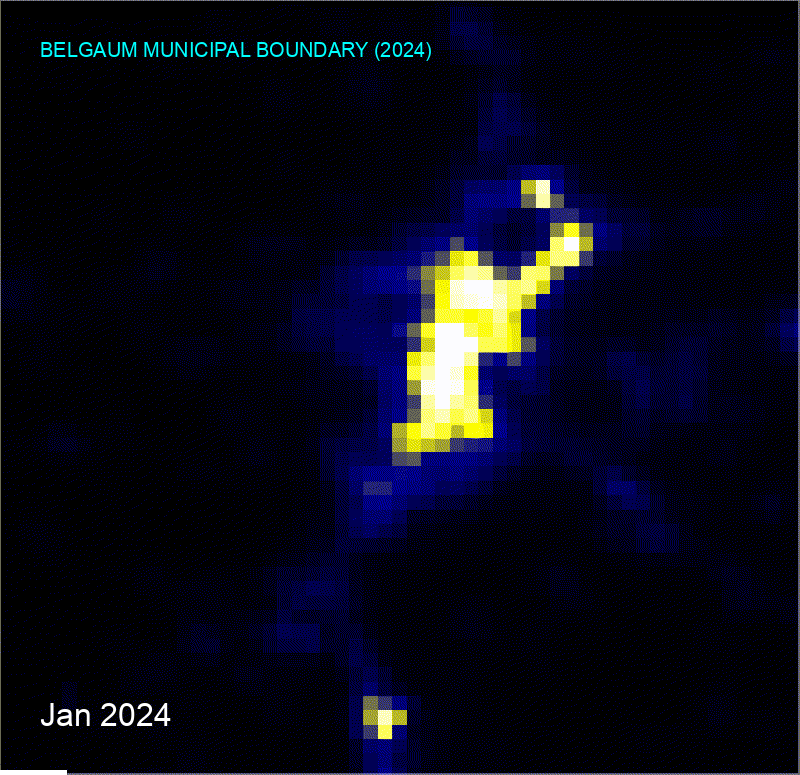


Success! Upload 'index.html' and 'belgaum_2024_final.gif' to GitHub to update your live link.


In [2]:
import ee
import geemap
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import Image

# 1. INITIALIZATION
# Ensure this project ID matches your Google Cloud Project
ee.Initialize(project='belgaum-492521')

# 2. SETTINGS & CONSTANTS
COST_PER_KWH = 7.00
CO2_PER_KWH = 0.8
K_LUMINOUS = 0.0012
belgaum_center = ee.Geometry.Point([74.50, 15.85])
roi = belgaum_center.buffer(12500).bounds()

# --- PART A: DATA PROCESSING ---
print("Step 1: Processing Satellite Imagery...")

boundary_outline = ee.Image().paint(roi, 0, 2).visualize(palette=['#ffffff'], opacity=0.4)

# Filter and Sort by time immediately
collection = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG") \
    .filterBounds(roi) \
    .filterDate('2024-01-01', '2024-12-31') \
    .sort('system:time_start')

def process_frame(img):
    mask = img.select('cf_cvg').gt(0)
    ntl_rad = img.select('avg_rad').updateMask(mask).clip(roi)

    ntl_rgb = ntl_rad.visualize(
        min=0, max=40,
        palette=['black', '#000044', '#000088', '#FFFF00', '#FFFFFF']
    )

    composite = ntl_rgb.blend(boundary_outline)
    kwh = ntl_rad.multiply(ee.Image.pixelArea()).multiply(K_LUMINOUS).rename('kWh')

    return composite.addBands([kwh, ntl_rad]).copyProperties(img, ['system:time_start'])

processed_coll = collection.map(process_frame)

# --- PART B: CHRONOLOGICAL DATA EXTRACTION ---
print("Step 2: Extracting Metrics and Fixing Sort Order...")

stats = processed_coll.map(lambda img: ee.Feature(None, {
    'date': img.date().format('MMM YYYY'),
    'timestamp': img.get('system:time_start'),
    'kWh': img.reduceRegion(ee.Reducer.sum(), roi, 463).getNumber('kWh')
})).getInfo()['features']

# Create DataFrame
df = pd.DataFrame([f['properties'] for f in stats])

# CRITICAL FIX: Convert to datetime and sort correctly
df['date_dt'] = pd.to_datetime(df['date'], format='%b %Y')
df = df.sort_values('date_dt')

df['INR_M'] = (df['kWh'] * COST_PER_KWH) / 1_000_000
df['CO2'] = df['kWh'] * CO2_PER_KWH

# --- PART C: INTERACTIVE DASHBOARD (COLAB COMPATIBLE) ---
pio.renderers.default = "colab" # Forces visibility in Google Colab

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(
    x=df['date'], y=df['kWh'], name="Energy (kWh)",
    line=dict(color='#2980b9', width=4, shape='spline'), fill='tozeroy',
    customdata=df['INR_M'],
    hovertemplate="<b>%{x}</b><br>Energy: %{y:,.0f} kWh<br>Cost: ₹%{customdata:.2f} M<extra></extra>"
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=df['date'], y=df['CO2'], name="CO2 Impact (kg)",
    line=dict(color='#e74c3c', width=2, dash='dot', shape='spline')
), secondary_y=True)

fig.update_layout(
    title='<b>Belgaum Urban Energy Pulse (2024)</b>',
    template='plotly_white',
    hovermode="x unified",
    xaxis=dict(title="Month", showgrid=False),
    yaxis=dict(title="Energy Consumption (kWh)")
)

fig.show()

# --- PART D: EXPORT & VIEW GIF ---
print("Step 3: Generating GIF...")
out_gif = "belgaum_2024_final.gif"
geemap.download_ee_video(processed_coll.select(['vis-red', 'vis-green', 'vis-blue']),
                         {'dimensions': 800, 'region': roi, 'framesPerSecond': 1},
                         out_gif)

geemap.add_text_to_gif(out_gif, out_gif, xy=('5%', '5%'),
                       text_sequence='BELGAUM MUNICIPAL BOUNDARY (2024)',
                       font_color='cyan', font_size=20)

geemap.add_text_to_gif(out_gif, out_gif, xy=('5%', '90%'),
                       text_sequence=df['date'].tolist(),
                       font_color='white', font_size=32, add_progress_bar=True)

# Preview GIF in Colab
display(Image(filename=out_gif))

# --- PART E: WEB DEPLOYMENT ---
fig.write_html("index.html")
print("\nSuccess! Upload 'index.html' and 'belgaum_2024_final.gif' to GitHub to update your live link.")

In [ ]:
df.to_csv('belgaum_energy_stats_2024.csv', index=False)
fig.write_html("index.html")
print("Files forced to sidebar. Click the Refresh icon in the file pane!")

Files forced to sidebar. Click the Refresh icon in the file pane!
